# <b> Graduation Project: Real-Estate-Price-Prediction<b>

### Imports

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
import matplotlib.pyplot as plt
import seaborn as sns





### Loading Dataset

In [3]:
df = pd.read_csv('properties.csv')

### Data Cleaning& Preprocessing

In [4]:
# # Enhanced Preprocessing with Categorical Mapping
# def preprocess_data(df):
#     # Clean and convert price
#     df['price'] = df['price'].replace('Ask', np.nan)
    
#     #added
#     # df['price'] = df['price'].astype(str).str.replace(',', '', regex=True)

#     df['price'] = pd.to_numeric(df['price'].str.replace(',', ''), errors='coerce')
#    #added
#     # df['price'] = pd.to_numeric(df['price'], errors='coerce')

#     # Convert numeric columns
#     numeric_columns = ['bedroom', 'bathroom', 'size_sqm']
#     for col in numeric_columns:
#         df[col] = pd.to_numeric(df[col], errors='coerce')
    
#     # Categorical Mapping
#     # 1. Property Type Mapping
#     type_mapping = {
#         'Duplex': 5,
#         'Villa': 8,
#         'Apartment': 3,
#         'Townhouse': 6,
#         'Penthouse': 7,
#         'iVilla': 6,
#         'Twin House': 5,
#         'Hotel Apartment': 4,
#         'Chalet': 4,
#         'Compound': 7
#     }
#     df['type_encoded'] = df['type'].map(type_mapping)
    
#     # 2. Location Complexity and Encoding
#     # Count number of location components as complexity
#     df['location_complexity'] = df['location'].str.count(',') + 1
    
#     # Create a Location Encoder
#     le_location = LabelEncoder()
#     df['location_encoded'] = le_location.fit_transform(df['location'])
    
#     # Feature Engineering
#     df['price_per_sqm'] = df['price'] / df['size_sqm']
#     df['room_density'] = df['bedroom'] / df['size_sqm']
#     df['bed_bath_ratio'] = df['bedroom'] / (df['bathroom'] + 1)
    
#     # Categorize property sizes
#     df['size_category'] = pd.cut(df['size_sqm'], 
#         bins=[0, 100, 200, 300, np.inf], 
#         labels=[1, 2, 3, 4])
    
#     # Drop rows with missing critical values
#     df_cleaned = df.dropna(subset=['price', 'bedroom', 'bathroom', 'size_sqm'])
    
#     # Prepare features and target
#     features = [
#         'type_encoded', 'location_encoded', 
#         'bedroom', 'bathroom', 'size_sqm', 
#         'price_per_sqm', 'room_density', 
#         'bed_bath_ratio', 'location_complexity',
#         'size_category'
#     ]

    
#     X = df_cleaned[features]
#     y = df_cleaned['price']
    
#     return X, y, le_location, type_mapping


In [5]:
def preprocess_data(df):
    # Clean and convert price
    df['price'] = df['price'].replace('Ask', np.nan)
    df['price'] = pd.to_numeric(df['price'].str.replace(',', ''), errors='coerce')

    # Convert numeric columns
    numeric_columns = ['bedroom', 'bathroom', 'size_sqm']
    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Categorical Mapping
    # 1. Property Type Mapping
    type_mapping = {
        'Duplex': 5,
        'Villa': 8,
        'Apartment': 3,
        'Townhouse': 6,
        'Penthouse': 7,
        'iVilla': 6,
        'Twin House': 5,
        'Hotel Apartment': 4,
        'Chalet': 4,
        'Compound': 7
    }
    df['type_encoded'] = df['type'].map(type_mapping)
    
    # 2. Location Complexity and Encoding
    # Count number of location components as complexity
    df['location_complexity'] = df['location'].str.count(',') + 1
    
    # Create a Location Encoder
    le_location = LabelEncoder()
    df['location_encoded'] = le_location.fit_transform(df['location'])
    
    # Feature Engineering - REMOVED price_per_sqm as it depends on the target
    df['room_density'] = df['bedroom'] / df['size_sqm']
    df['bed_bath_ratio'] = df['bedroom'] / (df['bathroom'] + 1)
    
    # Categorize property sizes
    df['size_category'] = pd.cut(df['size_sqm'], 
        bins=[0, 100, 200, 300, np.inf], 
        labels=[1, 2, 3, 4])
    
    # Drop rows with missing critical values
    df_cleaned = df.dropna(subset=['price', 'bedroom', 'bathroom', 'size_sqm'])
    
    # Prepare features and target
    features = [
        'type_encoded', 'location_encoded', 
        'bedroom', 'bathroom', 'size_sqm', 
        'room_density', 'bed_bath_ratio', 
        'location_complexity', 'size_category'
    ]
    
    X = df_cleaned[features]
    y = df_cleaned['price']
    
    return X, y, le_location, type_mapping


In [6]:
# Call data preprocessing function -- assigning X: Features, Y: Target "price" -- Location and Type encoding
X, y, le_location, type_mapping = preprocess_data(df)

In [7]:
# Printing DF
print(df.head(20)) 
df.to_json('DFPreprocessedJson.json', orient='records', lines=True)
df.to_csv('DFPreprocessedCSV.csv', index=False)

         type                                              title  \
0      Duplex     Prime Location Duplex Fully Finished With A\C    
1       Villa  Town house resale at Mivida Emaar with best price   
2   Apartment   Lake View Residence - Apartment | Prime Location   
3   Townhouse  Best Penthouse for sale in villette ( sky conds )   
4   Penthouse  2nd Floor | Fully Finished | Lowest Price |Par...   
5   Apartment  Amazing Delivered Villa  Below market price at...   
6       Villa   Under market Price Apart. In tag sultan for sale   
7   Townhouse  Apartment with installments at Lake View Resid...   
8   Apartment      0% DP over 9 y f.finished apartment for sale    
9   Apartment    Villa Modern  Hyde Park 327M under market price   
10  Apartment  Apartment 235m for sale  in Rehab             ...   
11      Villa  Finished | Ground + Garden | Overlooking Main ...   
12      Villa  For sale penthouse in mountain view hyde park ...   
13  Apartment  Villa for sale immediate receipt 

## Useing XGBoost Algorithm

In [8]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-Fold CV


In [9]:
# Define XGBoost model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,  # L1 regularization (lasso)
    reg_lambda=0.1,  # L2 regularization (ridge)
    random_state=42
)

In [10]:
# Standardization Preprocessing
xgbpreprocessor = ColumnTransformer([
    ('num', StandardScaler(), X.columns.tolist())
])

# Create pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', xgbpreprocessor),
    ('regressor', xgb_model)
])

In [11]:
cv_scores = cross_val_score(xgb_pipeline, X, y, cv=kf, scoring='r2')


In [12]:
# Print results
print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean R² Score: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation: {np.std(cv_scores):.4f}")

Cross-Validation R² Scores: [0.18037927 0.50764258 0.63456527 0.68017313 0.23446285]
Mean R² Score: 0.4474
Standard Deviation: 0.2047


In [13]:
# xgb_pipeline.fit(X, y)
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'regressor__n_estimators': [300, 500, 700],  # Increase upper limit to 700
    'regressor__max_depth': [4, 6, 8],  # Reduce high depth to avoid overfitting
    'regressor__learning_rate': [0.01, 0.03, 0.05, 0.1],  # More refined tuning
    'regressor__subsample': [0.6, 0.75, 0.9],  # More granular control
    'regressor__colsample_bytree': [0.6, 0.8, 0.9],  # Keep 0.9 for feature selection
    'regressor__reg_alpha': [0, 0.1, 0.5, 1.0],  # L1 regularization (lasso) to reduce variance
    'regressor__reg_lambda': [0.1, 0.5, 1.0, 2.0]  # L2 regularization (ridge) to reduce overfitting
}

grid_search = RandomizedSearchCV(
    xgb_pipeline, param_distributions=param_grid, 
    n_iter=20, cv=5, scoring="r2", random_state=42, n_jobs=-1
)

grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'regressor__subsample': 0.75, 'regressor__reg_lambda': 2.0, 'regressor__reg_alpha': 0.5, 'regressor__n_estimators': 700, 'regressor__max_depth': 4, 'regressor__learning_rate': 0.01, 'regressor__colsample_bytree': 0.6}


In [14]:
# chossing best model
best_model = grid_search.best_estimator_
best_model.fit(X, y)  # Train on full dataset

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['type_encoded',
                                                   'location_encoded',
                                                   'bedroom', 'bathroom',
                                                   'size_sqm', 'room_density',
                                                   'bed_bath_ratio',
                                                   'location_complexity',
                                                   'size_category'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsa...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.01,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=700, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [15]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(grid_search.best_estimator_, X, y, cv=kf, scoring="r2")

print(f"Mean R² Score: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation: {np.std(cv_scores):.4f}")

Mean R² Score: 0.5537
Standard Deviation: 0.1866


In [16]:
# from sklearn.model_selection import StratifiedKFold

# # Bin prices into categories
# y_binned = pd.cut(y, bins=5, labels=False)  # Create price categories

# kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# cv_scores = cross_val_score(grid_search.best_estimator_, X, y_binned, cv=kf, scoring="r2")

# print(f"Mean R² Score: {np.mean(cv_scores):.4f}")
# print(f"Standard Deviation: {np.std(cv_scores):.4f}")

In [17]:
# def predict_property_price_xgb(type_str, location_str, bedrooms, bathrooms, size_sqm):
#     # Map property type
#     type_encoded = type_mapping.get(type_str, 3)  # Default to Apartment if not found

#     # Handle unseen locations
#     if location_str in le_location.classes_:
#         location_encoded = le_location.transform([location_str])[0]
#     else:
#         location_encoded = -1  # Assign unknown locations a default value

#     # Compute additional features
#     room_density = bedrooms / size_sqm
#     bed_bath_ratio = bedrooms / (bathrooms + 1)
#     location_complexity = location_str.count(',') + 1
#     size_category = pd.cut([size_sqm], bins=[0, 100, 200, 300, np.inf], labels=[1, 2, 3, 4])[0]

#     # Create input DataFrame **without price_per_sqm**
#     input_data = pd.DataFrame({
#         'type_encoded': [type_encoded],
#         'location_encoded': [location_encoded],
#         'bedroom': [bedrooms],
#         'bathroom': [bathrooms],
#         'size_sqm': [size_sqm],
#         'room_density': [room_density],
#         'bed_bath_ratio': [bed_bath_ratio],
#         'location_complexity': [location_complexity],
#         'size_category': [size_category]
#     })

#     # Ensure input columns match training columns
#     missing_cols = set(X.columns) - set(input_data.columns)
#     for col in missing_cols:
#         input_data[col] = 0  # Assign default value for missing columns

#     # Ensure correct column order
#     input_data = input_data[X.columns]

#     # Predict price
#     predicted_price = best_model.predict(input_data)[0]
    
#     return predicted_price


In [18]:
def predict_property_price_xgb(type_str, location_str, bedrooms, bathrooms, size_sqm):
    # Map property type
    type_encoded = type_mapping.get(type_str, 3)  # Default to Apartment if not found

    # Handle unseen locations
    if location_str in le_location.classes_:
        location_encoded = le_location.transform([location_str])[0]
    else:
        location_encoded = -1  # Assign unknown locations a default value

    # Compute additional features
    room_density = bedrooms / size_sqm
    bed_bath_ratio = bedrooms / (bathrooms + 1)
    location_complexity = location_str.count(',') + 1
    size_category = pd.cut([size_sqm], bins=[0, 100, 200, 300, np.inf], labels=[1, 2, 3, 4])[0]

    # Create input DataFrame - no price_per_sqm needed
    input_data = pd.DataFrame({
        'type_encoded': [type_encoded],
        'location_encoded': [location_encoded],
        'bedroom': [bedrooms],
        'bathroom': [bathrooms],
        'size_sqm': [size_sqm],
        'room_density': [room_density],
        'bed_bath_ratio': [bed_bath_ratio],
        'location_complexity': [location_complexity],
        'size_category': [size_category]
    })

    # Ensure input columns match training columns
    missing_cols = set(X.columns) - set(input_data.columns)
    for col in missing_cols:
        input_data[col] = 0  # Assign default value for missing columns

    # Ensure correct column order
    input_data = input_data[X.columns]

    # Predict price
    predicted_price = best_model.predict(input_data)[0]
    
    return predicted_price


In [19]:
predicted_price = predict_property_price_xgb(
    type_str='Villa',
    location_str='Al Burouj Compound, El Shorouk Compounds, Shorouk City, Cairo',
    bedrooms=4,
    bathrooms=4,
    size_sqm=345
)

print(f"\nPredicted Property Price: {predicted_price:,.2f} EGP")


Predicted Property Price: 7,563,295.00 EGP


### Saving Best Model for XGBoost

In [20]:
import joblib

# Save the model
joblib.dump(best_model, "xgboost_real_estate_BestModel.pkl")

print("Model saved successfully!")

Model saved successfully!


In [21]:
# import xgboost as xgb
# import skl2onnx
# from skl2onnx import convert_sklearn
# from skl2onnx.common.data_types import FloatTensorType

# # Load the trained model
# num_features = X.shape[1]
# model = xgb.Booster()
# model.load_model("xgboost_real_estate_model.json")  # Use JSON instead of pkl

# # Convert to ONNX format
# initial_type = [("input", FloatTensorType([None, num_features]))]  # Adjust input shape
# onnx_model = convert_sklearn(model, initial_types=initial_type)

# # Save as ONNX file
# with open("model.onnx", "wb") as f:
#     f.write(onnx_model.SerializeToString())


## Visualizations and Plots

### Feature Importance Plot

In [22]:
# Split data into training and testing sets (20% test size)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the best model on training data
best_model.fit(X_train, y_train)

# Predict on test set
y_pred = best_model.predict(X_test)

# Create DataFrame for comparison
comparison_df = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred})

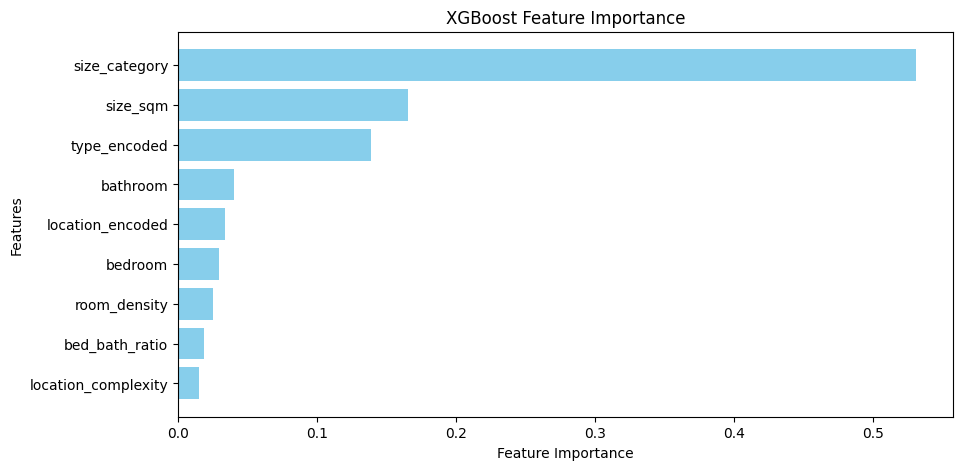

In [23]:

# Get feature importance from best model
feature_importances = best_model.named_steps['regressor'].feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()  # Highest at the top
plt.show()


 #### What we noticed from this plot
From the plot we learn that the most important - high weigh feature is price / SQM 

## Predicted vs. Actual Prices

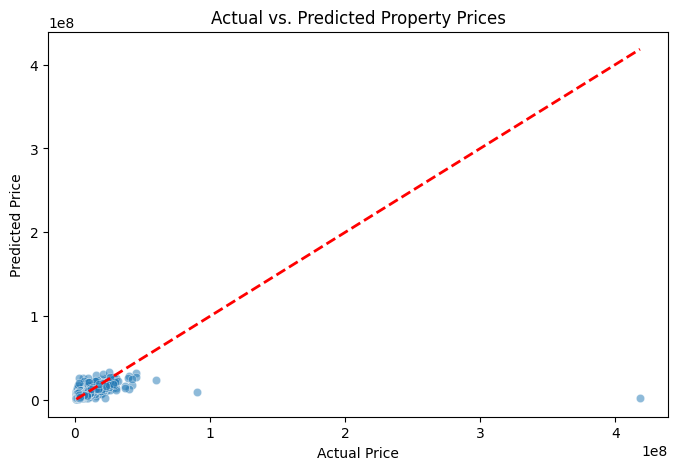

In [24]:

# Predict on test set
y_pred = best_model.predict(X_test)

# Create DataFrame
comparison_df = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred})

# Scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Actual Price', y='Predicted Price', data=comparison_df, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)  # Perfect fit line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted Property Prices")
plt.show()


 #### What we noticed from this plot
Most points are relativly close to the red line, predictions are accurate.



### Residual Plot (Error Distribution)

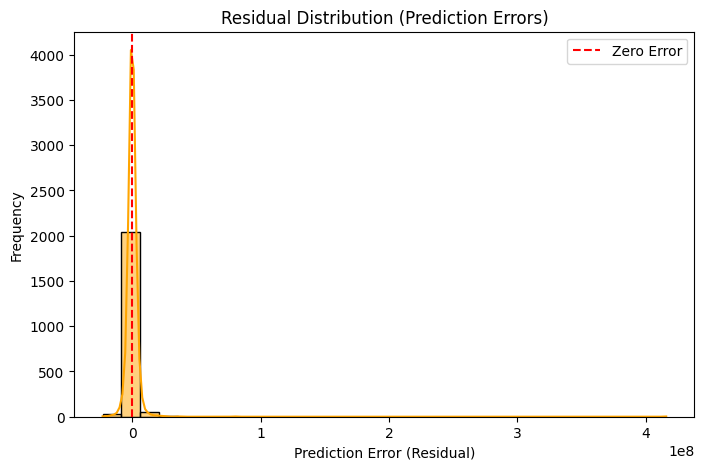

In [25]:
# Calculate residuals (errors)
residuals = y_test - y_pred

# Plot residual distribution
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True, color='orange')
plt.axvline(x=0, color='red', linestyle='--', label="Zero Error")
plt.xlabel("Prediction Error (Residual)")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Prediction Errors)")
plt.legend()
plt.show()


#### What we noticed from this plot
errors are centered around 0, the model is well-calibrated. <br>
If the plot was skewed, it suggests bias in predictions.

### Price Distribution

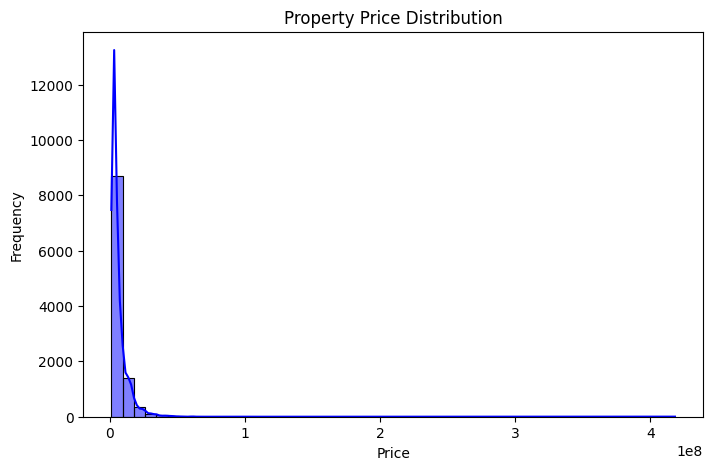

Exception ignored in: <function ResourceTracker.__del__ at 0x7d8613391080>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7ae1afa7d080>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x77bc42879080>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/reso

In [26]:
plt.figure(figsize=(8, 5))
sns.histplot(y, bins=50, kde=True, color='blue')
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Property Price Distribution")
plt.show()

 #### What we noticed from this plot
 Distribution is Left-Skewed (Long Tail on the Left) <br>
 Many high-priced properties, few budget homes. <br>
 Cause: The dataset might be focused on luxury homes. <br>
 Action: Collect more low/mid-range property data for better balance. <br>